In [1]:
# Run this cell only if pandas/matplotlib
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn --quiet
print("Libraries available.")


Libraries available.


In [2]:
import os, glob
print("Current working directory:", os.getcwd())
files = glob.glob("*")
print("Files in current folder:", files)

# show only csvs
csvs = sorted([f for f in files if f.lower().endswith(".csv")])
print("\nCSV files found:", csvs if csvs else "No CSVs found — upload the CSVs to this folder.")


Current working directory: C:\Users\nelis
Files in current folder: ['anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'customers.csv', 'Desktop', 'Documents', 'Downloads', 'Ecomm.ipynb', 'Ecommerce_Dashboard.pbix', 'Ecommerce_Dashboard_Screenshot.png', 'employee', 'Favorites', 'final(2).csv', 'game platform', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{822392a0-83f7-11ef-a159-9f9cf2f84730}.TM.blf', 'NTUSER.DAT{822392a0-83f7-11ef-a159-9f9cf2f84730}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{822392a0-83f7-11ef-a159-9f9cf2f84730}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'orders.csv', 'order_items.csv', 'payments.csv', 'Platform based', 'Platform Based Development', 'Postman', 'PrintHood', 'products.csv', 'PycharmProjects', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'source', 'Start Menu', 'Templates', 'T

In [3]:
import pandas as pd
import glob, os

# expected base names
expected = {
    "customers": ["customers.csv", "customer.csv"],
    "products": ["products.csv", "product.csv"],
    "orders": ["orders.csv", "order.csv"],
    "order_items": ["order_items.csv", "orderitems.csv", "order_items_.csv"],
    "payments": ["payments.csv", "payment.csv"]
}

found = {}
for key, names in expected.items():
    for name in names:
        if os.path.exists(name):
            found[key] = name
            break

# if not found, try any file with keyword in name
for key in expected:
    if key not in found:
        matches = [f for f in glob.glob("*.csv") if key in f.lower()]
        if matches:
            found[key] = matches[0]

print("Files used (or None if not found):")
for k in expected:
    print(f"  {k}: {found.get(k)}")

# Load or create empty DataFrame with warning
dfs = {}
for k in expected:
    path = found.get(k)
    if path:
        try:
            dfs[k] = pd.read_csv(path)
            print(f"Loaded {k} from {path}, rows: {len(dfs[k])}")
        except Exception as e:
            print(f"ERROR loading {path}: {e}")
            dfs[k] = pd.DataFrame()
    else:
        print(f"WARNING: {k} file not found.")
        dfs[k] = pd.DataFrame()

# assign to named variables for convenience
customers = dfs['customers']
products = dfs['products']
orders = dfs['orders']
order_items = dfs['order_items']
payments = dfs['payments']


Files used (or None if not found):
  customers: customers.csv
  products: products.csv
  orders: orders.csv
  order_items: order_items.csv
  payments: payments.csv
Loaded customers from customers.csv, rows: 5
Loaded products from products.csv, rows: 7
Loaded orders from orders.csv, rows: 5
Loaded order_items from order_items.csv, rows: 7
Loaded payments from payments.csv, rows: 4


In [4]:
def show_cols(name, df):
    print(f"\n{name} columns ({len(df.columns)}):")
    if df.empty:
        print("  <empty dataframe>")
    else:
        print("  ", list(df.columns))

show_cols("customers", customers)
show_cols("products", products)
show_cols("orders", orders)
show_cols("order_items", order_items)
show_cols("payments", payments)



customers columns (9):
   ['Customer_id', 'First_name', 'Last_name', 'Email', 'Phone', 'Address', 'City', 'Country', 'Created_at']

products columns (6):
   ['Product_id', 'Product_name', 'Category', 'Price', 'Stock_Quantity', 'Created_at']

orders columns (4):
   ['Order_id', 'Customer_id', 'Order_date', 'Status']

order_items columns (5):
   ['Order_Item_id', 'Order_id', 'Product_id', 'Quantity', 'Price']

payments columns (5):
   ['Payment_id', 'Order_id', 'Amount', 'Payment_date', 'Payment_method']


In [5]:
# standardize names everywhere: strip and lowercase
for df_name, df in [('customers', customers), ('products', products), ('orders', orders), 
                    ('order_items', order_items), ('payments', payments)]:
    if not df.empty:
        df.columns = df.columns.str.strip().str.lower()
        print(f"{df_name} -> columns normalized")
    else:
        print(f"{df_name} is empty; skipped normalization")

# show columns again
show_cols("products", products)
show_cols("order_items", order_items)


customers -> columns normalized
products -> columns normalized
orders -> columns normalized
order_items -> columns normalized
payments -> columns normalized

products columns (6):
   ['product_id', 'product_name', 'category', 'price', 'stock_quantity', 'created_at']

order_items columns (5):
   ['order_item_id', 'order_id', 'product_id', 'quantity', 'price']


In [6]:
# check typical key columns
print("Check important keys exist:")
keys = {
    "products": "product_id",
    "order_items": "product_id",
    "orders": "order_id",
    "payments": "order_id",
    "customers": "customer_id"
}
for dfname, key in keys.items():
    df = locals().get(dfname)
    exists = (not df.empty) and (key in df.columns)
    print(f"  {dfname}: has '{key}'? -> {exists}")


Check important keys exist:
  products: has 'product_id'? -> True
  order_items: has 'product_id'? -> True
  orders: has 'order_id'? -> True
  payments: has 'order_id'? -> True
  customers: has 'customer_id'? -> True


In [7]:
# create a safe 'price' column in order_items by coalescing available columns
oi = order_items.copy()

# list of potential price column names to check in order_items and products
possible_price_cols_oi = ['price','price_x','price_y','unit_price','rice']  # 'rice' seen earlier might be typo
possible_price_cols_prod = ['price','product_price','list_price']

def coalesce_price(row, oi_cols, prod_df):
    # not used in vectorized code; kept for logic clarity
    return None

# fix products price column to 'price' if possible
for col in possible_price_cols_prod:
    if col in products.columns:
        products = products.rename(columns={col: 'price'})
        break

# attempt to create order_items['price']:
# 1) if order_items already has 'price' do nothing
# 2) else if price_x or price_y exist, prefer 'price' if present then price_x then price_y
# 3) else pull from products by merging temporarily
if 'price' not in oi.columns:
    # try price_x, price_y or unit_price or rice
    for col in possible_price_cols_oi:
        if col in oi.columns:
            oi['price'] = oi[col]
            print(f"Created oi['price'] from oi['{col}']")
            break

# if still no price, merge product price
if 'price' not in oi.columns:
    if 'product_id' in oi.columns and 'product_id' in products.columns and 'price' in products.columns:
        oi = oi.merge(products[['product_id','price']], on='product_id', how='left')
        print("Merged product price into order_items")
    else:
        print("WARNING: Could not find price in order_items or products. You will need to inspect your files.")

# ensure quantity exists and numeric
if 'quantity' not in oi.columns:
    # try alternative names
    alt_qty = [c for c in oi.columns if 'qty' in c or 'quantity' in c]
    if alt_qty:
        oi.rename(columns={alt_qty[0]: 'quantity'}, inplace=True)
        print(f"Renamed {alt_qty[0]} -> quantity")
    else:
        print("WARNING: 'quantity' column not found in order_items. Check file.")

# convert to numeric, fill nans with 0
oi['price'] = pd.to_numeric(oi['price'], errors='coerce').fillna(0)
oi['quantity'] = pd.to_numeric(oi['quantity'], errors='coerce').fillna(0)

# assign back
order_items = oi

print("\nFinal order_items columns:", order_items.columns.tolist())



Final order_items columns: ['order_item_id', 'order_id', 'product_id', 'quantity', 'price']


In [8]:
# Metrics
order_items['line_total'] = order_items['price'] * order_items['quantity']

total_sales = order_items['line_total'].sum()
total_orders = orders['order_id'].nunique() if (not orders.empty and 'order_id' in orders.columns) else len(orders)
average_order_value = total_sales / total_orders if total_orders else 0
total_customers = customers['customer_id'].nunique() if (not customers.empty and 'customer_id' in customers.columns) else 0
total_payments = payments['amount'].sum() if (not payments.empty and 'amount' in payments.columns) else 0

# Nicely formatted print
import locale
try:
    locale.setlocale(locale.LC_ALL, '')
except Exception:
    pass

print(f"\nTotal Sales: {total_sales:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: {average_order_value:,.2f}")
print(f"Total Customers: {total_customers}")
print(f"Total Payments: {total_payments:,.2f}")



Total Sales: 59,100.00
Total Orders: 5
Average Order Value: 11,820.00
Total Customers: 5
Total Payments: 56,600.00


In [10]:
# Sales by product_id and join product names if available
prod_names = products[['product_id','product_name']].drop_duplicates() if 'product_name' in products.columns else None
sales_by_product = order_items.groupby('product_id')['line_total'].sum().reset_index().sort_values('line_total', ascending=False)
if prod_names is not None:
    sales_by_product = sales_by_product.merge(prod_names, on='product_id', how='left')

display(sales_by_product.head(10))

# Sales by category if products has category
if 'category' in products.columns:
    sib = order_items.merge(products[['product_id','category']], on='product_id', how='left')
    sales_by_category = sib.groupby('category')['line_total'].sum().reset_index().sort_values('line_total', ascending=False)
    display(sales_by_category)
else:
    print("No 'category' column found in products.")


,product_id,line_total,product_name
0,2,25000.0,iPhone 14
1,1,12000.0,Laptop HP 250 G8
2,3,10000.0,Samsung TV 55 Inch
3,7,4500.0,Wooden Desk
4,4,3600.0,Nike Air Max
5,6,2500.0,Office Chair
6,5,1500.0,Adidas T-shirt


,category,line_total
1,Electronics,47000.0
2,Furniture,7000.0
0,Clothing,5100.0


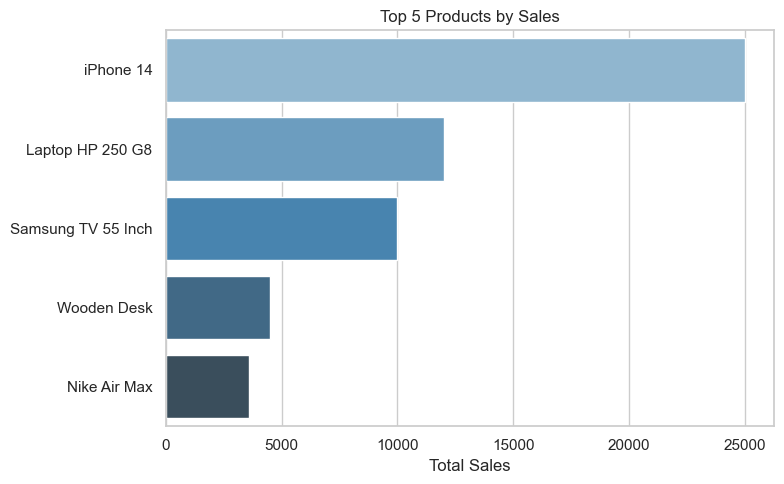

C:\Users\nelis\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\nelis\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


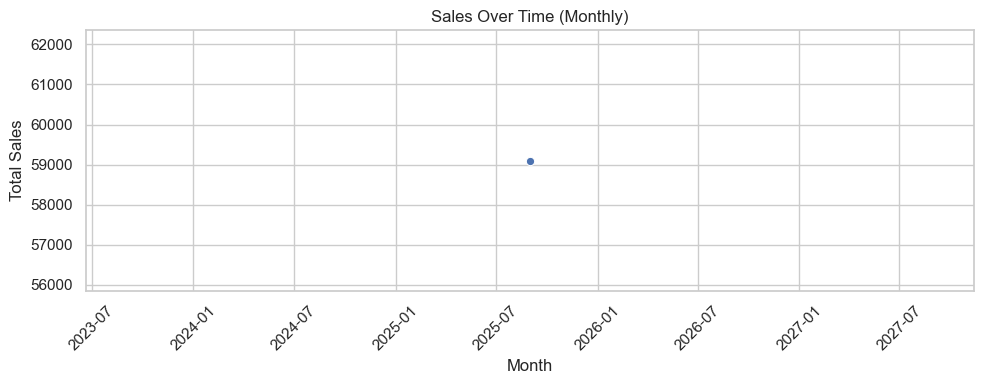

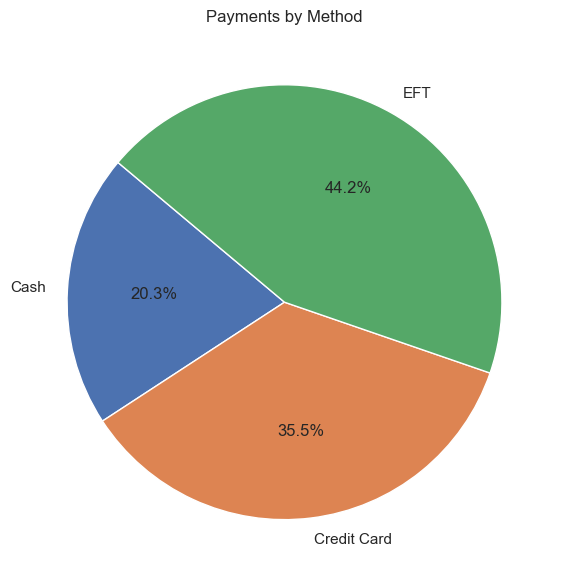

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Top 5 products by sales
top5 = sales_by_product.head(5)
plt.figure(figsize=(8,5))
sns.barplot(y='product_name' if 'product_name' in top5.columns else 'product_id', x='line_total', data=top5, palette="Blues_d")
plt.title("Top 5 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Sales over time (month)
if 'order_date' in orders.columns:
    orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
    oi_with_date = order_items.merge(orders[['order_id','order_date']], on='order_id', how='left')
    oi_with_date['month'] = oi_with_date['order_date'].dt.to_period('M')
    sales_month = oi_with_date.groupby('month')['line_total'].sum().reset_index()
    sales_month['month'] = sales_month['month'].dt.to_timestamp()
    plt.figure(figsize=(10,4))
    sns.lineplot(x='month', y='line_total', data=sales_month, marker='o')
    plt.title("Sales Over Time (Monthly)")
    plt.xlabel("Month")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No 'order_date' in orders -> skipping sales over time plot")

# Payment method distribution (if available)
if 'payment_method' in payments.columns and 'amount' in payments.columns:
    pm = payments.groupby('payment_method')['amount'].sum().reset_index()
    plt.figure(figsize=(6,6))
    plt.pie(pm['amount'], labels=pm['payment_method'], autopct='%1.1f%%', startangle=140)
    plt.title("Payments by Method")
    plt.tight_layout()
    plt.show()
else:
    print("No payment_method/amount in payments -> skipping payments pie chart")


In [12]:
# create an output folder
out = "output"
os.makedirs(out, exist_ok=True)

order_items.to_csv(os.path.join(out, "order_items_clean.csv"), index=False)
sales_by_product.to_csv(os.path.join(out, "sales_by_product.csv"), index=False)

summary = {
    "total_sales": total_sales,
    "total_orders": total_orders,
    "average_order_value": average_order_value,
    "total_customers": total_customers,
    "total_payments": total_payments
}
pd.DataFrame([summary]).to_csv(os.path.join(out, "summary_metrics.csv"), index=False)
print("Saved cleaned data and summary to ./output/")


Saved cleaned data and summary to ./output/
